In the previous expanded dataset iteration, we created a model with an r^2 value of 0.28. Markedly better than our first iteration, but still in need of improvement. One factor we failed to account for earlier was the Goldschmidt Tolerance Factor: an empirical measurement of the geometrical limitations of perovskite structures. In this iteration, we implement this additional feature. Because the tolerance factor encodes structural geometry that composition-based features cannot capture, we expect it to improve predictive accuracy.

In [1]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")

In [ ]:
# Import helper functions and global vars from utils
from utils import query_materials_project, ionic_radii, compute_tolerance_factor, halides, metals

In [3]:
halide_families = [[metal, halide] for metal in metals for halide in halides]
df =  query_materials_project(MY_API_KEY, halide_families, 3)

print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Retrieving SummaryDoc documents:   0%|          | 0/24 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/23 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/35 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/15 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/9 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/13 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/24 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/32 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/23 [00:00<?, ?it/s]

Found 198 materials after cleaning
      formula  band_gap  energy_above_hull  formation_energy      volume  \
0     Pb3BrO3    0.6278           0.165773         -1.254862  693.961454   
1     Pb3BrF5    2.9997           0.181058         -2.268123  252.758669   
2       PbBrF    2.6154           0.173193         -1.813667  134.204090   
3       PbIBr    2.5657           0.168709         -0.938913  440.317969   
4  Pb7(BrO4)2    1.1409           0.184565         -1.235309  799.398026   

    density  nsites  
0  7.173757      28  
1  5.232710       9  
2  7.574955       6  
3  6.245280      12  
4  7.221320      34  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
dtype: int64


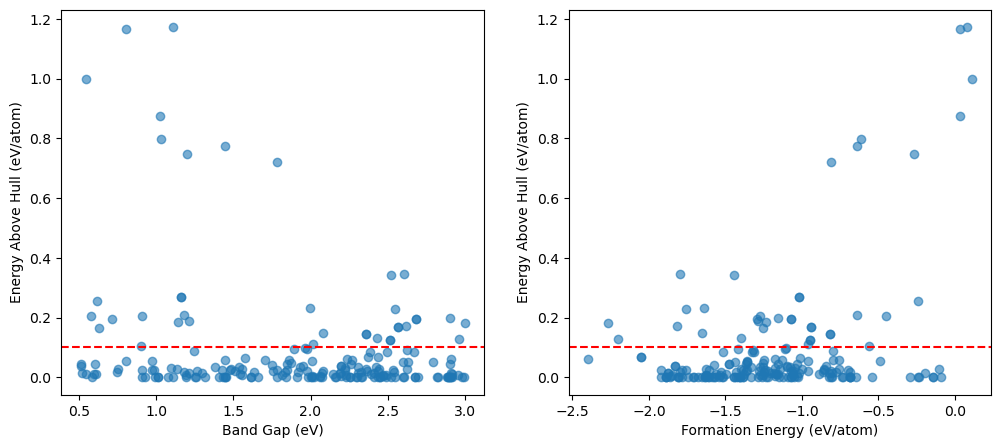

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

In [ ]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id = "composition", ignore_errors=True)

# Adding the Goldschmidt tolerance factor to the dataframe
df["tolerance_factor"] = df["composition"].apply(compute_tolerance_factor)

StrToComposition:   0%|          | 0/198 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/198 [00:00<?, ?it/s]

117
A_site
O     20
Tl    18
In    16
F     13
S     11
P      7
Th     5
Mo     3
Pd     2
Se     2
As     2
Sb     2
Zr     2
C      2
N      1
W      1
Name: count, dtype: int64


STEP 3: Training and Testing Model

Running an 80/20 train/test split

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Cleaning non-numeric features from the dataframe as the model cannot use them
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])

X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 81 materials with 133 features


In [7]:
# split our data into the test and training sets using 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Display number of samples in training and testing sets
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Train the model: Here we create 100 different trees for the random forest,
# and set a random state for reproducability
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")

Training set: 64 samples
Testing set: 17 samples
Mean Absolute Error: 0.0269 eV/atom
R² Score: 0.2964


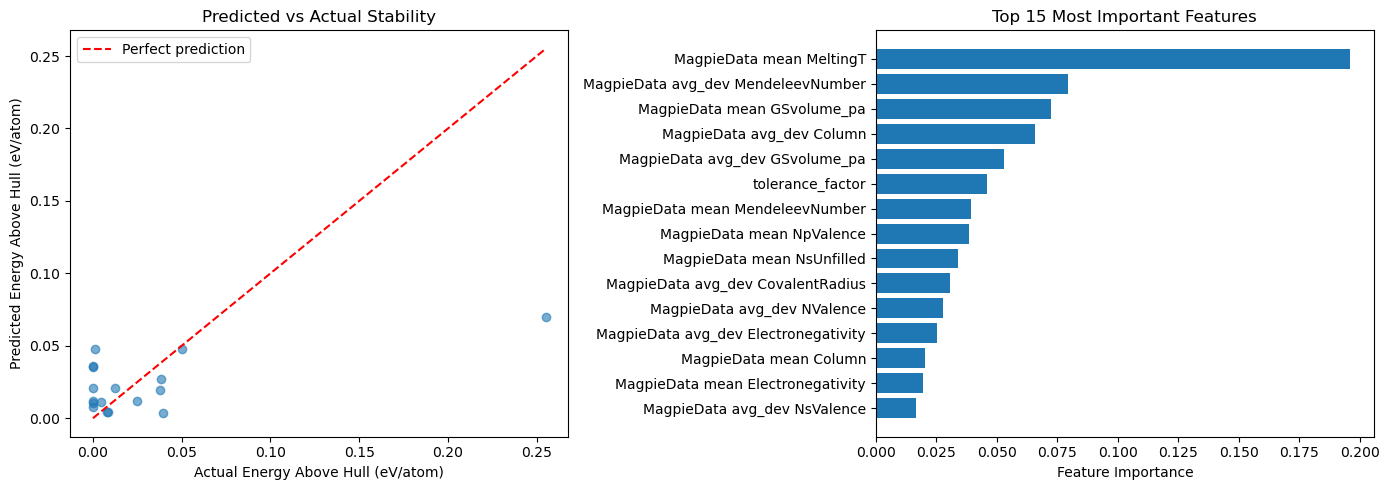

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

In this iteration of the notebook, we had to limit the query to ABX3 structures in order to use the Goldschmidt Tolerance Factor in our features. In either case, our dataset was severely limited, causing a drop in R^2 values, and the predictive power of the model. For the next iteration, we will include non-ABX3 structures to both expand the dataset and to be more reflective of actual photovoltaic applications: some of the most effective perovskites used now do not fall under the ABX3 structure. Adding the tolerance factor initially appeared to improve R² to 0.615, but restricting to clean ABX3 structures revealed this was partially inflated by non-perovskite entries — the corrected R² on a clean dataset is 0.296.